In [ ]:
import kagglehub
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt
import shutil
import os


## Download ed organizzazione dataset

In [ ]:
path = pathlib.Path(kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection"))

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Path to dataset files: /kaggle/input/brain-mri-images-for-brain-tumor-detection


In [ ]:
DATA_PATH = pathlib.Path("./data")

if DATA_PATH.exists():
    shutil.rmtree(DATA_PATH)

shutil.copytree(path, DATA_PATH)

shutil.rmtree(DATA_PATH / "brain_tumor_dataset")

In [ ]:
!pip install split-folders

In [ ]:
def find_invalid_images(directory):
    invalid_files = []
    for root, _, files in os.walk(directory):
        for f in files:
            file_path = os.path.join(root, f)
            try:
                img_bytes = tf.io.read_file(file_path)
                _ = tf.image.decode_image(img_bytes)
            except tf.errors.InvalidArgumentError:
                invalid_files.append(file_path)
            except Exception as e:
                print(f"An unexpected error occurred with file {file_path}: {e}")
                invalid_files.append(file_path)
    return invalid_files

def remove_files(file_list):
    for file_path in file_list:
        try:
            os.remove(file_path)
            print(f"Removed: {file_path}")
        except OSError as e:
            print(f"Error removing file {file_path}: {e}")

In [ ]:
IMAGES_PATH = DATA_PATH
invalid_files = find_invalid_images(IMAGES_PATH)
remove_files(invalid_files)

In [ ]:
import splitfolders

SPLITTED = pathlib.Path("./SPLITTED")

splitfolders.ratio(DATA_PATH, output = SPLITTED, ratio = (0.7, 0.2, 0.1), group_prefix = None)

Copying files: 253 files [00:00, 4178.79 files/s]


In [ ]:
train_dir = SPLITTED / "train"
val_dir = SPLITTED / "val"
test_dir = SPLITTED / "test"

SEED = 42
BATCH_SIZE = 16
IMG_SIZE = (256, 256)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = True,
    seed = SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    seed = SEED
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = True,
    seed = SEED
)

train_dataset = train_dataset.cache().prefetch(2)
validation_dataset = validation_dataset.cache().prefetch(2)
test_dataset = test_dataset.cache().prefetch(2)

Found 176 files belonging to 2 classes.
Found 50 files belonging to 2 classes.
Found 27 files belonging to 2 classes.


## Modelli

## SONO SCAN MRI, QUINDI FARò PRIMA UN MODELLO CON TRANSFER LEARNING E POI UN MODELLO CON TRANSFER LEARNING CON CLAHE + CANNY NEL PREPROCESSING

## Modello Tranfer Learning no CLAHE no Canny

In [ ]:
backbone = tf.keras.applications.EfficientNetB4(
    include_top = False,
    weights = "imagenet",
    input_shape = IMG_SIZE + (3,)
)

backbone.trainable = False

In [ ]:
classification_heads = tf.keras.models.Sequential(
    [
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(1, activation = "sigmoid")
    ]
)

In [ ]:
preprocess_input = tf.keras.applications.efficientnet.preprocess_input

In [ ]:
inputs = tf.keras.layers.Input(shape = IMG_SIZE + (3,))
x = tf.keras.layers.RandomFlip("horizontal")(inputs)
x = tf.keras.layers.GaussianNoise(stddev=0.1)(x)
x = preprocess_input(x)
x = backbone(x)
outputs = classification_heads(x)
model = tf.keras.Model(inputs, outputs)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

learning_rate_adapter = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3
)

checkpoint_model = tf.keras.callbacks.ModelCheckpoint(
    filepath="./best.keras",
    monitor="val_loss",
    save_best_only=True
)

checkpoint_weights = tf.keras.callbacks.ModelCheckpoint(
    filepath="./best.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True
)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate = 0.0001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
'''
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=100,
    callbacks=[
        early_stopping,
        learning_rate_adapter,
        checkpoint_model,
        checkpoint_weights
    ]
)
'''

'\nhistory = model.fit(\n    train_dataset,\n    validation_data=validation_dataset,\n    epochs=100,\n    callbacks=[\n        early_stopping,\n        learning_rate_adapter,\n        checkpoint_model,\n        checkpoint_weights\n    ]\n)\n'

In [ ]:
# best_model = tf.keras.models.load_model("./best.keras")

# model.load_weights("./best.weights.h5")

In [ ]:
# results = model.evaluate(test_dataset)
# print("Test Loss:", results[0])
# print("Test Accuracy:", results[1])

## ACCURACY SUL TEST DELL'80% (200 epoche di training)

## STESSO MODELLO MA CON CLAHE E CANNY

In [ ]:
import tensorflow as tf
import cv2
import numpy as np

In [ ]:
def clahe_canny_tf(image):
    """
    Applica CLAHE e l'algoritmo di Canny a un tensore immagine di TensorFlow.
    """
    def _apply_clahe_canny(img):
        # Converte il tensore in un array NumPy per poter usare OpenCV
        img = img.numpy()

        # --- FASE 1: CLAHE (Contrast Limited Adaptive Histogram Equalization) ---
        # Converte da RGB a YUV: lavoriamo sul canale Y (luminanza) per non alterare i colori
        img_yuv = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2YUV)

        # Crea l'oggetto CLAHE:
        # - clipLimit=2.0: limita l'amplificazione del contrasto per evitare rumore eccessivo
        # - tileGridSize=(8, 8): divide l'immagine in una griglia 8x8 per l'equalizzazione locale
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img_yuv[:,:,0] = clahe.apply(img_yuv[:,:,0])

        # Riconverte in RGB dopo aver migliorato il contrasto
        clahe_img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

        # --- FASE 2: CANNY EDGE DETECTION ---
        # Converte in scala di grigi, necessario per l'algoritmo di Canny
        gray_clahe = cv2.cvtColor(clahe_img, cv2.COLOR_RGB2GRAY)

        # Applica Canny:
        # - 100: Soglia inferiore (pixel sotto 100 vengono scartati)
        # - 200: Soglia superiore (pixel sopra 200 sono considerati bordi certi)
        canny_img = cv2.Canny(gray_clahe, 100, 200)

        # Converte l'output di Canny (1 solo canale) in 3 canali (RGB)
        # per mantenere la compatibilità con l'input della rete (es. EfficientNet)
        canny_img_3_channels = cv2.cvtColor(canny_img, cv2.COLOR_GRAY2RGB)

        return tf.convert_to_tensor(canny_img_3_channels, dtype=tf.float32)

    # tf.py_function è necessario perché OpenCV non è nativo di TensorFlow.
    # Permette di eseguire codice Python/NumPy arbitrario come un'operazione del grafo.
    processed_image = tf.py_function(
        _apply_clahe_canny,
        [image],            # Lista degli argomenti di input
        Tout=tf.float32     # Tipo di dato atteso in output
    )

    # Poiché py_function perde le informazioni sulla forma del tensore (shape),
    # dobbiamo riassegnarla manualmente basandoci sull'input originale.
    processed_image.set_shape(image.get_shape())

    return processed_image

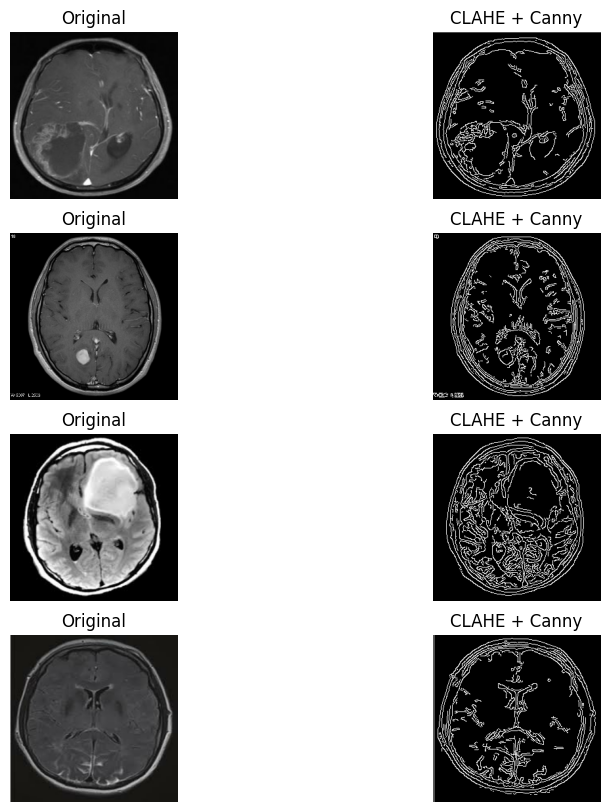

In [ ]:
import matplotlib.pyplot as plt

# Get a batch of images from the training dataset
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(min(4, BATCH_SIZE)):
        original_image = images[i]

        # Apply CLAHE and Canny
        processed_image = clahe_canny_tf(original_image)

        # Original Image
        plt.subplot(min(4, BATCH_SIZE), 2, 2 * i + 1)
        plt.imshow(original_image.numpy().astype("uint8"))
        plt.title("Original")
        plt.axis("off")

        # Processed Image
        plt.subplot(min(4, BATCH_SIZE), 2, 2 * i + 2)
        # Ensure the processed image is in the correct type and range for imshow
        plt.imshow(processed_image.numpy().astype("uint8"))
        plt.title("CLAHE + Canny")
        plt.axis("off")
    plt.show()

In [ ]:
inputs = tf.keras.layers.Input(shape = IMG_SIZE + (3,))

# 1. Data Augmentation
x = tf.keras.layers.RandomFlip("horizontal")(inputs)

# 2. Custom Preprocessing (CLAHE + Canny)
# Utilizziamo Lambda per integrare la funzione custom nel grafo Keras
x = tf.keras.layers.Lambda(lambda img: tf.map_fn(clahe_canny_tf, img))(x)

# 3. Model-specific Preprocessing
x = preprocess_input(x)

# 4. Feature Extraction & Classification
x = backbone(x)
outputs = classification_heads(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate = 0.0001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy'],
    # Disabilitiamo la compilazione JIT (XLA) per permettere l'uso di tf.py_function (OpenCV)
    # all'interno del grafo del modello durante il training su GPU.
    jit_compile=False
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=100,
    callbacks=[
        early_stopping,
        learning_rate_adapter,
        checkpoint_model,
        checkpoint_weights
    ]
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 634ms/step - accuracy: 0.8295 - loss: 0.4045 - val_accuracy: 0.8000 - val_loss: 0.4353 - learning_rate: 1.0000e-04
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8523 - loss: 0.4215 - val_accuracy: 0.8000 - val_loss: 0.4349 - learning_rate: 1.0000e-04
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 482ms/step - accuracy: 0.8580 - loss: 0.3865 - val_accuracy: 0.8000 - val_loss: 0.4345 - learning_rate: 1.0000e-04
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 616ms/step - accuracy: 0.8864 - loss: 0.4119 - val_accuracy: 0.8000 - val_loss: 0.4343 - learning_rate: 1.0000e-04
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 492ms/step - accuracy: 0.8523 - loss: 0.3858 - val_accuracy: 0.8000 - val_loss: 0.4342 - learning_rate: 1.0000e-04
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 540ms/step - accuracy: 0.8750 - loss: 0.3997 - val_accuracy: 0.8000 - val_loss: 0.4342 - learning_rate: 1.0000e-04
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 493ms/step - accu

In [ ]:
# Soluzione 1: Caricare i pesi nel modello esistente (Raccomandato)
# Dato che il modello è già definito sopra, basta caricare i pesi.
model.load_weights("./best.weights.h5")
print("Pesi caricati con successo nel modello esistente.")

# Soluzione 2: Se vuoi proprio usare load_model, devi passare la funzione custom
try:
    best_model = tf.keras.models.load_model(
        "./best.keras",
        custom_objects={'clahe_canny_tf': clahe_canny_tf},
        safe_mode=False
    )
    print("Modello completo caricato con successo.")
except Exception as e:
    print(f"Errore nel caricamento del modello completo: {e}")

Pesi caricati con successo nel modello esistente.
Errore nel caricamento del modello completo: Exception encountered when calling Lambda.call().

We could not automatically infer the shape of the Lambda's output. Please specify the `output_shape` argument for this Lambda layer.

Arguments received by Lambda.call():
  • args=('<KerasTensor shape=(None, 256, 256, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_4013>',)
  • kwargs={'mask': 'None'}


In [ ]:
results = model.evaluate(test_dataset)
print("Test Loss:", results[0])
print("Test Accuracy:", results[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step - accuracy: 0.7778 - loss: 0.5719
Test Loss: 0.5718734860420227
Test Accuracy: 0.7777777910232544


## ACCURATEZZA SUL TEST SET DEL